# ICDAR Mini Benchmark Evaluation

This notebook evaluates and compares OCR vs VLM performance on the ICDAR mini dataset.

**Phases:**
- **Phase 1**: OCR Baseline (azure_intelligence, donut, mistral_document_ai)
- **Phase 2**: VLM Baseline with generic prompts (gpt-5-mini, gpt-5-nano)
- **Phase 3a**: VLM with task-aware prompts (gpt-5-mini, gpt-5-nano)

**Key Questions:**
1. Which models perform best for text extraction?
2. Do VLMs outperform traditional OCR?
3. Does prompting improve VLM performance (Phase 2 vs Phase 3)?

## 1. Import Required Libraries

In [21]:
%pip install matplotlib seaborn pandas numpy openpyxl ms sklearn

/Users/kenzabenkirane/Documents/GitHub/research-playground/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from typing import List, Dict, Optional
import warnings
warnings.filterwarnings('ignore')

# Text similarity metrics
try:
    import editdistance
    HAS_EDITDISTANCE = True
except ImportError:
    HAS_EDITDISTANCE = False
    print("editdistance not installed. Install with: pip install editdistance")

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)

# Plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("Libraries loaded successfully!")

Libraries loaded successfully!


## 2. Load Dataset and Results

Load the consolidated results from the postprocessing folder.

In [23]:
# Define paths
RESULTS_DIR = Path("../results_postprocessing/ICDAR_mini")

# Load consolidated results for each phase
phase_1_df = pd.read_csv(RESULTS_DIR / "phase_1_consolidated.csv")
phase_2_df = pd.read_csv(RESULTS_DIR / "phase_2_consolidated.csv")
phase_3a_df = pd.read_csv(RESULTS_DIR / "phase_3a_consolidated.csv")

# Load summary
summary_df = pd.read_csv(RESULTS_DIR / "all_phases_summary.csv")

print("Phase 1 (OCR Baseline):", phase_1_df.shape)
print("Phase 2 (VLM Baseline):", phase_2_df.shape)
print("Phase 3a (VLM + Context):", phase_3a_df.shape)
print("\nSummary shape:", summary_df.shape)

Phase 1 (OCR Baseline): (500, 23)
Phase 2 (VLM Baseline): (500, 17)
Phase 3a (VLM + Context): (500, 17)

Summary shape: (7, 13)


In [24]:
# Display summary table
print("Model Performance Summary:")
print("=" * 80)
summary_df

Model Performance Summary:


,model,phase,total_samples,avg_inference_time_ms,median_inference_time_ms,min_inference_time_ms,max_inference_time_ms,error_count,error_rate,avg_tokens,total_tokens,predictions_count,prediction_rate
0,azure_intelligence,phase_1,500,2990.463852,2578.134418,2441.274166,1.629352e+04,0,0.0,NaN,0.0,492,98.4
1,donut,phase_1,500,36080.416965,521.450162,415.915012,9.723301e+06,0,0.0,NaN,0.0,500,100.0
2,mistral_document_ai,phase_1,500,2075.686383,1829.905868,658.253193,2.300197e+04,0,0.0,NaN,0.0,500,100.0
3,gpt-5-mini,phase_2,500,10586.443673,9956.387043,3108.565092,4.868794e+04,0,0.0,NaN,0.0,494,98.8
4,gpt-5-nano,phase_2,500,12062.920298,12085.169911,3980.895281,2.206505e+04,0,0.0,NaN,0.0,329,65.8
5,gpt-5-mini,phase_3a,500,11391.359913,10820.323467,3134.683847,2.466551e+04,0,0.0,NaN,0.0,476,95.2
6,gpt-5-nano,phase_3a,500,12821.826241,13358.394027,3621.594191,2.176087e+04,0,0.0,NaN,0.0,251,50.2


## 3. Parse and Normalize Outputs

Extract prediction columns and normalize text for comparison.

In [25]:
def normalize_text(text: str) -> str:
    """Normalize text for comparison."""
    if pd.isna(text) or text is None:
        return ""
    text = str(text).strip()
    # Replace multiple whitespace with single space
    text = ' '.join(text.split())
    # Remove ### markers (used for redacted content in ground truth)
    text = text.replace("###", "").strip()
    return text

def get_model_names_from_df(df: pd.DataFrame) -> List[str]:
    """Extract model names from column prefixes."""
    models = set()
    for col in df.columns:
        if col.endswith('_prediction'):
            model = col.replace('_prediction', '')
            models.add(model)
    return sorted(list(models))

# Get model names for each phase
phase_1_models = get_model_names_from_df(phase_1_df)
phase_2_models = get_model_names_from_df(phase_2_df)
phase_3a_models = get_model_names_from_df(phase_3a_df)

print("Phase 1 models (OCR):", phase_1_models)
print("Phase 2 models (VLM baseline):", phase_2_models)
print("Phase 3a models (VLM + context):", phase_3a_models)

Phase 1 models (OCR): ['azure_intelligence', 'donut', 'mistral_document_ai']
Phase 2 models (VLM baseline): ['gpt-5-mini', 'gpt-5-nano']
Phase 3a models (VLM + context): ['gpt-5-mini', 'gpt-5-nano']


## 4. Calculate Character Error Rate (CER)

CER measures the edit distance at the character level, normalized by the length of the ground truth.

In [26]:
def levenshtein_distance(s1: str, s2: str) -> int:
    """Calculate Levenshtein distance between two strings."""
    if HAS_EDITDISTANCE:
        return editdistance.eval(s1, s2)
    
    # Fallback implementation
    if len(s1) < len(s2):
        return levenshtein_distance(s2, s1)
    if len(s2) == 0:
        return len(s1)
    
    previous_row = range(len(s2) + 1)
    for i, c1 in enumerate(s1):
        current_row = [i + 1]
        for j, c2 in enumerate(s2):
            insertions = previous_row[j + 1] + 1
            deletions = current_row[j] + 1
            substitutions = previous_row[j] + (c1 != c2)
            current_row.append(min(insertions, deletions, substitutions))
        previous_row = current_row
    return previous_row[-1]

def calculate_cer(ground_truth: str, prediction: str) -> float:
    """Calculate Character Error Rate."""
    gt = normalize_text(ground_truth)
    pred = normalize_text(prediction)
    
    if len(gt) == 0:
        return 0.0 if len(pred) == 0 else 1.0
    
    distance = levenshtein_distance(gt, pred)
    return distance / len(gt)

def calculate_wer(ground_truth: str, prediction: str) -> float:
    """Calculate Word Error Rate."""
    gt_words = normalize_text(ground_truth).split()
    pred_words = normalize_text(prediction).split()
    
    if len(gt_words) == 0:
        return 0.0 if len(pred_words) == 0 else 1.0
    
    distance = levenshtein_distance(gt_words, pred_words)
    return distance / len(gt_words)

# Test the functions
test_gt = "Hello World"
test_pred = "Helo Warld"
print(f"Ground truth: '{test_gt}'")
print(f"Prediction: '{test_pred}'")
print(f"CER: {calculate_cer(test_gt, test_pred):.4f}")
print(f"WER: {calculate_wer(test_gt, test_pred):.4f}")

Ground truth: 'Hello World'
Prediction: 'Helo Warld'
CER: 0.1818
WER: 1.0000


In [27]:
def calculate_metrics_for_phase(df: pd.DataFrame, models: List[str]) -> pd.DataFrame:
    """Calculate CER and WER for all models in a phase."""
    results = []
    
    for model in models:
        pred_col = f"{model}_prediction"
        
        if pred_col not in df.columns:
            continue
        
        for idx, row in df.iterrows():
            gt = row.get('ground_truth', '')
            pred = row.get(pred_col, '')
            
            # Skip if no ground truth
            if pd.isna(gt) or normalize_text(gt) == '':
                continue
            
            cer = calculate_cer(gt, pred)
            wer = calculate_wer(gt, pred)
            
            results.append({
                'sample_id': row['sample_id'],
                'model': model,
                'ground_truth_len': len(normalize_text(gt)),
                'prediction_len': len(normalize_text(pred)) if not pd.isna(pred) else 0,
                'cer': cer,
                'wer': wer,
                'has_prediction': not pd.isna(pred) and normalize_text(pred) != ''
            })
    
    return pd.DataFrame(results)

# Calculate metrics for Phase 1 (OCR)
print("Calculating metrics for Phase 1 (OCR)...")
phase_1_metrics = calculate_metrics_for_phase(phase_1_df, phase_1_models)
print(f"  Computed {len(phase_1_metrics)} measurements")

# Calculate metrics for Phase 2 (VLM baseline)
print("Calculating metrics for Phase 2 (VLM baseline)...")
phase_2_metrics = calculate_metrics_for_phase(phase_2_df, phase_2_models)
print(f"  Computed {len(phase_2_metrics)} measurements")

# Calculate metrics for Phase 3a (VLM + context)
print("Calculating metrics for Phase 3a (VLM + context)...")
phase_3a_metrics = calculate_metrics_for_phase(phase_3a_df, phase_3a_models)
print(f"  Computed {len(phase_3a_metrics)} measurements")

Calculating metrics for Phase 1 (OCR)...
  Computed 1500 measurements
Calculating metrics for Phase 2 (VLM baseline)...
  Computed 1000 measurements
Calculating metrics for Phase 3a (VLM + context)...
  Computed 1000 measurements


## 5. Calculate Word Error Rate (WER)

Generate summary statistics for WER across all models and phases.

In [28]:
def summarize_metrics(metrics_df: pd.DataFrame, phase_name: str) -> pd.DataFrame:
    """Generate summary statistics for each model."""
    if len(metrics_df) == 0:
        return pd.DataFrame()
    
    summary = metrics_df.groupby('model').agg({
        'cer': ['mean', 'median', 'std', 'min', 'max'],
        'wer': ['mean', 'median', 'std', 'min', 'max'],
        'has_prediction': ['sum', 'count'],
        'ground_truth_len': 'mean',
        'prediction_len': 'mean'
    }).round(4)
    
    # Flatten column names
    summary.columns = ['_'.join(col).strip() for col in summary.columns.values]
    summary['phase'] = phase_name
    summary['prediction_rate'] = (summary['has_prediction_sum'] / summary['has_prediction_count'] * 100).round(1)
    
    return summary.reset_index()

# Generate summaries
phase_1_summary = summarize_metrics(phase_1_metrics, 'Phase 1 (OCR)')
phase_2_summary = summarize_metrics(phase_2_metrics, 'Phase 2 (VLM)')
phase_3a_summary = summarize_metrics(phase_3a_metrics, 'Phase 3a (VLM+)')

# Combine all summaries
all_summaries = pd.concat([phase_1_summary, phase_2_summary, phase_3a_summary], ignore_index=True)
all_summaries

,model,cer_mean,cer_median,cer_std,cer_min,cer_max,wer_mean,wer_median,wer_std,wer_min,wer_max,has_prediction_sum,has_prediction_count,ground_truth_len_mean,prediction_len_mean,phase,prediction_rate
0,azure_intelligence,0.6135,0.5274,0.6163,0.0,5.7500,0.8770,0.7550,0.8075,0.0,9.0,492,500,74.402,84.976,Phase 1 (OCR),98.4
1,donut,4.0861,1.0000,15.0991,0.5,171.2222,4.8097,1.0000,37.7272,0.5,765.0,500,500,74.402,179.492,Phase 1 (OCR),100.0
2,mistral_document_ai,4.4431,1.0000,25.0349,0.0,358.7143,3.7362,1.0000,34.7652,0.0,723.5,500,500,74.402,222.790,Phase 1 (OCR),100.0
3,gpt-5-mini,2.6295,0.5988,9.2593,0.0,152.5000,2.5527,0.8000,5.9356,0.0,80.0,494,500,74.402,140.554,Phase 2 (VLM),98.8
4,gpt-5-nano,1.8491,0.9563,7.1537,0.0,120.5000,1.8447,1.0000,4.4987,0.0,53.0,329,500,74.402,47.556,Phase 2 (VLM),65.8
5,gpt-5-mini,0.5142,0.5000,0.3818,0.0,3.6731,0.7507,0.7321,0.5405,0.0,6.4,476,500,74.402,61.054,Phase 3a (VLM+),95.2
6,gpt-5-nano,0.7309,1.0000,0.4068,0.0,4.5000,0.8508,1.0000,0.4156,0.0,3.0,251,500,74.402,14.590,Phase 3a (VLM+),50.2


## 6. Compare Model Performance

Create comprehensive comparison tables showing OCR vs VLM performance.

In [29]:
# Create a clean comparison table
comparison_cols = ['model', 'phase', 'cer_mean', 'cer_median', 'wer_mean', 'wer_median', 'prediction_rate']
comparison_df = all_summaries[comparison_cols].copy()
comparison_df.columns = ['Model', 'Phase', 'CER (Mean)', 'CER (Median)', 'WER (Mean)', 'WER (Median)', 'Pred Rate %']

# Sort by CER mean
comparison_df = comparison_df.sort_values('CER (Mean)')
print("Model Performance Comparison (sorted by CER):")
print("=" * 100)
comparison_df

Model Performance Comparison (sorted by CER):


,Model,Phase,CER (Mean),CER (Median),WER (Mean),WER (Median),Pred Rate %
5,gpt-5-mini,Phase 3a (VLM+),0.5142,0.5000,0.7507,0.7321,95.2
0,azure_intelligence,Phase 1 (OCR),0.6135,0.5274,0.8770,0.7550,98.4
6,gpt-5-nano,Phase 3a (VLM+),0.7309,1.0000,0.8508,1.0000,50.2
4,gpt-5-nano,Phase 2 (VLM),1.8491,0.9563,1.8447,1.0000,65.8
3,gpt-5-mini,Phase 2 (VLM),2.6295,0.5988,2.5527,0.8000,98.8
1,donut,Phase 1 (OCR),4.0861,1.0000,4.8097,1.0000,100.0
2,mistral_document_ai,Phase 1 (OCR),4.4431,1.0000,3.7362,1.0000,100.0


In [30]:
# Compare VLM performance: Phase 2 vs Phase 3a (Does prompting help?)
vlm_models = set(phase_2_models) & set(phase_3a_models)
print("VLM Models in both Phase 2 and Phase 3a:", vlm_models)
print()

if vlm_models:
    print("Impact of Prompting on VLM Performance:")
    print("=" * 80)
    for model in sorted(vlm_models):
        p2_stats = phase_2_summary[phase_2_summary['model'] == model]
        p3a_stats = phase_3a_summary[phase_3a_summary['model'] == model]
        
        if len(p2_stats) > 0 and len(p3a_stats) > 0:
            cer_p2 = p2_stats['cer_mean'].values[0]
            cer_p3a = p3a_stats['cer_mean'].values[0]
            wer_p2 = p2_stats['wer_mean'].values[0]
            wer_p3a = p3a_stats['wer_mean'].values[0]
            
            cer_improvement = ((cer_p2 - cer_p3a) / cer_p2 * 100) if cer_p2 > 0 else 0
            wer_improvement = ((wer_p2 - wer_p3a) / wer_p2 * 100) if wer_p2 > 0 else 0
            
            print(f"\n{model}:")
            print(f"  CER: {cer_p2:.4f} (Phase 2) → {cer_p3a:.4f} (Phase 3a) | Change: {cer_improvement:+.1f}%")
            print(f"  WER: {wer_p2:.4f} (Phase 2) → {wer_p3a:.4f} (Phase 3a) | Change: {wer_improvement:+.1f}%")
            
            if cer_improvement > 0:
                print(f"  ✓ Prompting IMPROVED CER by {cer_improvement:.1f}%")
            elif cer_improvement < 0:
                print(f"  ✗ Prompting WORSENED CER by {abs(cer_improvement):.1f}%")
            else:
                print(f"  = Prompting had NO EFFECT on CER")

VLM Models in both Phase 2 and Phase 3a: {'gpt-5-nano', 'gpt-5-mini'}

Impact of Prompting on VLM Performance:

gpt-5-mini:
  CER: 2.6295 (Phase 2) → 0.5142 (Phase 3a) | Change: +80.4%
  WER: 2.5527 (Phase 2) → 0.7507 (Phase 3a) | Change: +70.6%
  ✓ Prompting IMPROVED CER by 80.4%

gpt-5-nano:
  CER: 1.8491 (Phase 2) → 0.7309 (Phase 3a) | Change: +60.5%
  WER: 1.8447 (Phase 2) → 0.8508 (Phase 3a) | Change: +53.9%
  ✓ Prompting IMPROVED CER by 60.5%


## 7. Visualize Results

Generate visualizations to compare model performance.

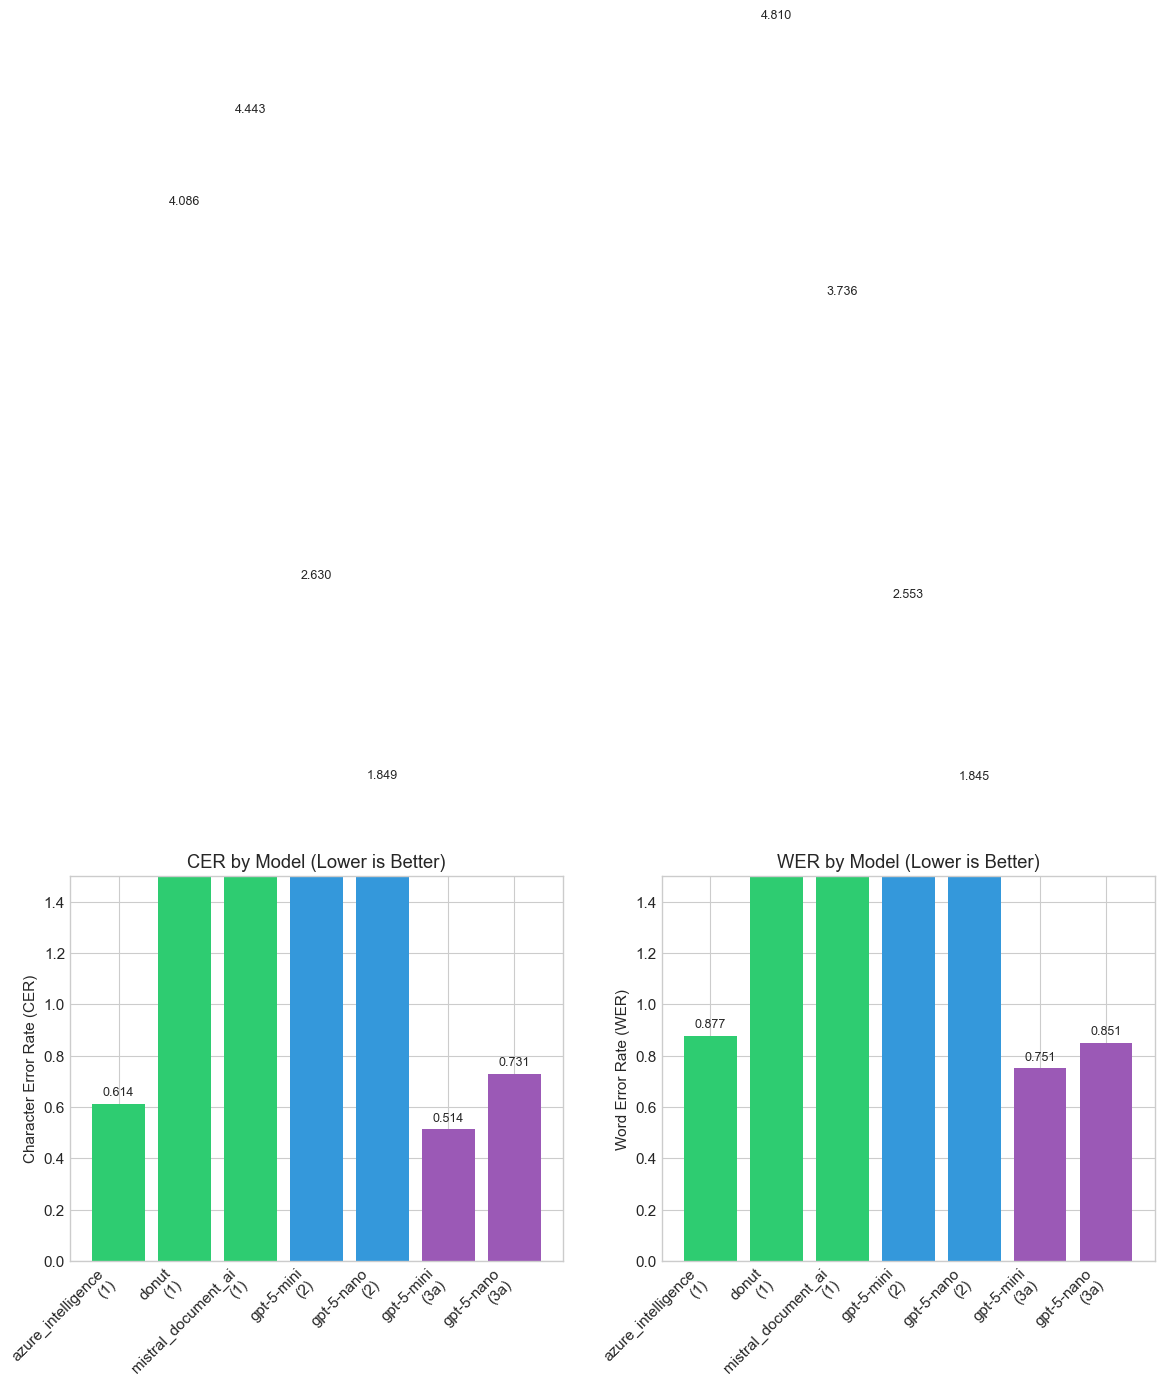

In [31]:
# Bar chart: CER by Model and Phase
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: CER Mean by Model
ax1 = axes[0]
colors = {'Phase 1 (OCR)': '#2ecc71', 'Phase 2 (VLM)': '#3498db', 'Phase 3a (VLM+)': '#9b59b6'}
x_positions = range(len(all_summaries))
bars = ax1.bar(x_positions, all_summaries['cer_mean'], 
               color=[colors.get(p, '#95a5a6') for p in all_summaries['phase']])
ax1.set_xticks(x_positions)
ax1.set_xticklabels([f"{row['model']}\n({row['phase'].split()[1]})" 
                      for _, row in all_summaries.iterrows()], rotation=45, ha='right')
ax1.set_ylabel('Character Error Rate (CER)')
ax1.set_title('CER by Model (Lower is Better)')
ax1.set_ylim(0, min(1.5, all_summaries['cer_mean'].max() * 1.2))

# Add value labels on bars
for bar, val in zip(bars, all_summaries['cer_mean']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
             f'{val:.3f}', ha='center', va='bottom', fontsize=9)

# Plot 2: WER Mean by Model
ax2 = axes[1]
bars = ax2.bar(x_positions, all_summaries['wer_mean'],
               color=[colors.get(p, '#95a5a6') for p in all_summaries['phase']])
ax2.set_xticks(x_positions)
ax2.set_xticklabels([f"{row['model']}\n({row['phase'].split()[1]})" 
                      for _, row in all_summaries.iterrows()], rotation=45, ha='right')
ax2.set_ylabel('Word Error Rate (WER)')
ax2.set_title('WER by Model (Lower is Better)')
ax2.set_ylim(0, min(1.5, all_summaries['wer_mean'].max() * 1.2))

# Add value labels on bars
for bar, val in zip(bars, all_summaries['wer_mean']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
             f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'cer_wer_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

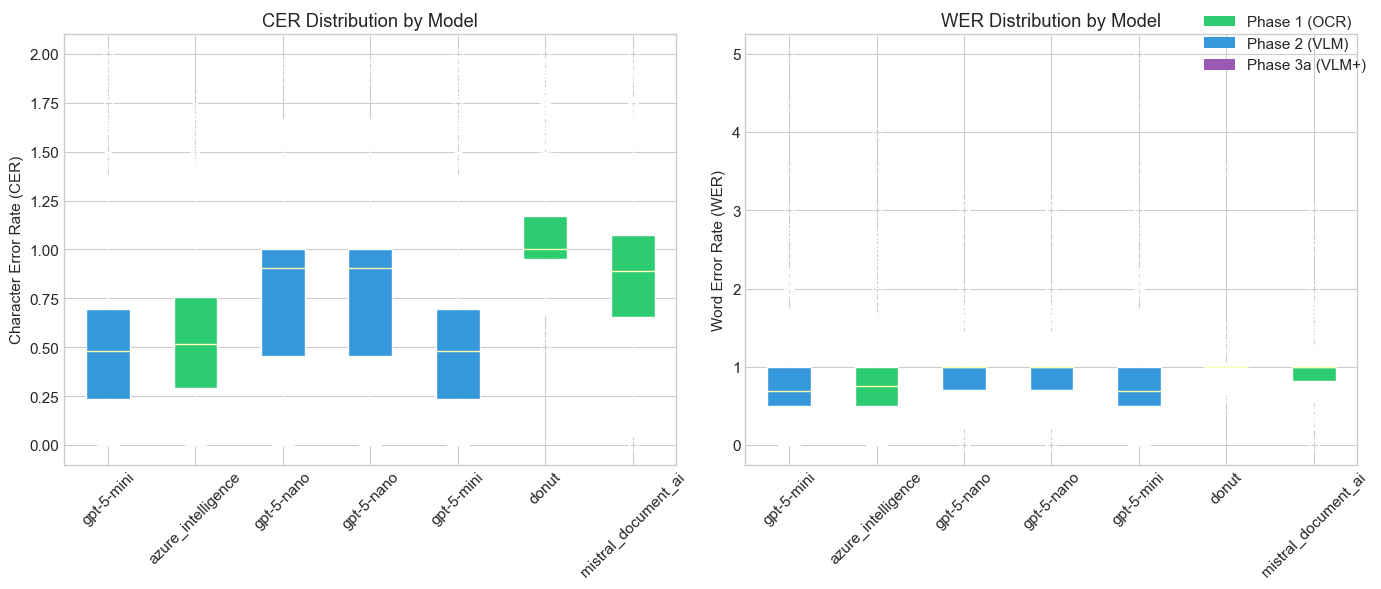

In [32]:
# Box plot: CER distribution by model
all_metrics = pd.concat([
    phase_1_metrics.assign(phase='Phase 1 (OCR)'),
    phase_2_metrics.assign(phase='Phase 2 (VLM)'),
    phase_3a_metrics.assign(phase='Phase 3a (VLM+)')
], ignore_index=True)

# Filter out extreme outliers for better visualization (CER > 2 is almost certainly noise)
filtered_metrics = all_metrics[all_metrics['cer'] <= 2.0]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Box plot for CER
ax1 = axes[0]
models_ordered = all_summaries.sort_values('cer_mean')['model'].tolist()
filtered_for_box = filtered_metrics[filtered_metrics['model'].isin(models_ordered)]

# Create box plot data
box_data_cer = [filtered_for_box[filtered_for_box['model'] == m]['cer'].values for m in models_ordered]
bp1 = ax1.boxplot(box_data_cer, labels=models_ordered, patch_artist=True)
for patch, model in zip(bp1['boxes'], models_ordered):
    phase = all_summaries[all_summaries['model'] == model]['phase'].values[0]
    patch.set_facecolor(colors.get(phase, '#95a5a6'))
ax1.set_ylabel('Character Error Rate (CER)')
ax1.set_title('CER Distribution by Model')
ax1.tick_params(axis='x', rotation=45)

# Box plot for WER
ax2 = axes[1]
box_data_wer = [filtered_for_box[filtered_for_box['model'] == m]['wer'].values for m in models_ordered]
bp2 = ax2.boxplot(box_data_wer, labels=models_ordered, patch_artist=True)
for patch, model in zip(bp2['boxes'], models_ordered):
    phase = all_summaries[all_summaries['model'] == model]['phase'].values[0]
    patch.set_facecolor(colors.get(phase, '#95a5a6'))
ax2.set_ylabel('Word Error Rate (WER)')
ax2.set_title('WER Distribution by Model')
ax2.tick_params(axis='x', rotation=45)

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=p) for p, c in colors.items()]
fig.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(0.99, 0.99))

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'cer_wer_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

In [33]:
# Phase comparison: OCR vs VLM
phase_comparison = all_metrics.groupby('phase').agg({
    'cer': ['mean', 'median', 'std'],
    'wer': ['mean', 'median', 'std'],
    'has_prediction': 'mean'
}).round(4)

phase_comparison.columns = ['_'.join(col) for col in phase_comparison.columns]
phase_comparison = phase_comparison.reset_index()
phase_comparison['has_prediction_mean'] = (phase_comparison['has_prediction_mean'] * 100).round(1)
phase_comparison.columns = ['Phase', 'CER Mean', 'CER Median', 'CER Std', 'WER Mean', 'WER Median', 'WER Std', 'Pred Rate %']

print("Phase-Level Comparison (OCR vs VLM vs VLM+Prompting):")
print("=" * 100)
phase_comparison

Phase-Level Comparison (OCR vs VLM vs VLM+Prompting):


,Phase,CER Mean,CER Median,CER Std,WER Mean,WER Median,WER Std,Pred Rate %
0,Phase 1 (OCR),3.0476,0.9565,16.9600,3.1410,1.0000,29.6500,99.5
1,Phase 2 (VLM),2.2393,0.7222,8.2788,2.1987,1.0000,5.2756,82.3
2,Phase 3a (VLM+),0.6225,0.6111,0.4089,0.8007,0.8571,0.4845,72.7


## 8. Sample-Level Analysis

Examine specific samples to understand where models succeed or fail.

In [34]:
# Find best and worst performing samples
# Pivot to compare same samples across models
sample_pivot = all_metrics.pivot_table(
    index='sample_id', 
    columns='model', 
    values='cer',
    aggfunc='first'
).reset_index()

# Calculate mean CER across all models for each sample
model_cols = [c for c in sample_pivot.columns if c != 'sample_id']
sample_pivot['mean_cer'] = sample_pivot[model_cols].mean(axis=1)
sample_pivot['std_cer'] = sample_pivot[model_cols].std(axis=1)

# Best samples (lowest mean CER)
print("Top 10 EASIEST Samples (lowest mean CER across all models):")
print("=" * 80)
print(sample_pivot.nsmallest(10, 'mean_cer')[['sample_id', 'mean_cer', 'std_cer']].to_string(index=False))

print("\n")
print("Top 10 HARDEST Samples (highest mean CER across all models):")
print("=" * 80)
print(sample_pivot.nlargest(10, 'mean_cer')[['sample_id', 'mean_cer', 'std_cer']].to_string(index=False))

Top 10 EASIEST Samples (lowest mean CER across all models):
         sample_id  mean_cer  std_cer
icdar_tr_img_03701  0.116000 0.217440
icdar_tr_img_09592  0.192593 0.430650
icdar_tr_img_09366  0.200000 0.405582
icdar_tr_img_06821  0.242718 0.451012
icdar_tr_img_06886  0.282353 0.442938
icdar_tr_img_09549  0.300000 0.379805
icdar_tr_img_09743  0.312000 0.421806
icdar_tr_img_03463  0.336970 0.413269
icdar_tr_img_05808  0.340000 0.127802
icdar_tr_img_05065  0.360000 0.478330


Top 10 HARDEST Samples (highest mean CER across all models):
         sample_id  mean_cer    std_cer
icdar_tr_img_00708 72.451429 160.027846
icdar_tr_img_08775 59.987500 130.371211
icdar_tr_img_01175 56.700000  73.751780
icdar_tr_img_03664 54.763158 120.997950
icdar_tr_img_06849 36.257143  47.073911
icdar_tr_img_06682 35.377778  75.967529
icdar_tr_img_00878 32.330435  68.578854
icdar_tr_img_05765 32.231579  72.042583
icdar_tr_img_05420 23.850000  47.764879
icdar_tr_img_03727 23.200000  27.244821


## 9. Language Analysis

Analyze performance by script/language if available.

In [35]:
# Define the 10 target languages
TARGET_LANGUAGES = ['Arabic', 'Bangla', 'Chinese', 'Hindi', 'Japanese', 'Korean', 'Latin', 'Mixed', 'None', 'Symbols']

def simplify_language(lang_str: str) -> str:
    """
    Simplify language string by selecting the non-Latin language when multiple are present.
    Example: 'Arabic, Latin' becomes 'Arabic'
    """
    if pd.isna(lang_str) or lang_str is None:
        return 'None'
    
    lang_str = str(lang_str).strip()
    
    # If only one language, return it
    if ',' not in lang_str:
        return lang_str
    
    # Split and find non-Latin language
    languages = [l.strip() for l in lang_str.split(',')]
    non_latin = [l for l in languages if l != 'Latin']
    
    if non_latin:
        return non_latin[0]  # Return first non-Latin language
    else:
        return 'Latin'  # All were Latin

# Apply to all dataframes
if 'language' in phase_1_df.columns:
    phase_1_df['language_simplified'] = phase_1_df['language'].apply(simplify_language)
    phase_2_df['language_simplified'] = phase_2_df['language'].apply(simplify_language)
    phase_3a_df['language_simplified'] = phase_3a_df['language'].apply(simplify_language)
    
    # Create language map from phase 1
    language_map = phase_1_df.set_index('sample_id')['language_simplified'].to_dict()
    all_metrics['language_simplified'] = all_metrics['sample_id'].map(language_map)
    
    # Show distribution
    print("Language Distribution (Simplified):")
    print("=" * 50)
    lang_counts = all_metrics.groupby('language_simplified')['sample_id'].nunique()
    print(lang_counts.sort_values(ascending=False).to_string())
else:
    print("No language column found in dataset")

Language Distribution (Simplified):
language_simplified
Symbols     83
None        66
Bangla      58
Hindi       49
Chinese     48
Mixed       47
Arabic      45
Japanese    43
Korean      35
Latin       17


In [36]:
# Filter to target languages only
metrics_filtered = all_metrics[all_metrics['language_simplified'].isin(TARGET_LANGUAGES)].copy()
print(f"Filtered to {len(metrics_filtered)} measurements across {TARGET_LANGUAGES}")
print(f"Unique samples: {metrics_filtered['sample_id'].nunique()}")
print(f"Models: {metrics_filtered['model'].unique().tolist()}")

Filtered to 3500 measurements across ['Arabic', 'Bangla', 'Chinese', 'Hindi', 'Japanese', 'Korean', 'Latin', 'Mixed', 'None', 'Symbols']
Unique samples: 491
Models: ['azure_intelligence', 'donut', 'mistral_document_ai', 'gpt-5-mini', 'gpt-5-nano']


### 9.1 Best Model per Language

Find which model performs best (lowest CER) for each of the 10 languages.

In [37]:
# Calculate mean CER and WER per language and model
lang_model_perf = metrics_filtered.groupby(['language_simplified', 'model']).agg({
    'cer': 'mean',
    'wer': 'mean',
    'sample_id': 'count'
}).round(4).reset_index()
lang_model_perf.columns = ['Language', 'Model', 'CER Mean', 'WER Mean', 'Sample Count']

# Find best model for each language (lowest CER)
best_model_by_language = lang_model_perf.loc[
    lang_model_perf.groupby('Language')['CER Mean'].idxmin()
][['Language', 'Model', 'CER Mean', 'WER Mean']]
best_model_by_language = best_model_by_language.sort_values('Language')

print("Best Model for Each Language (by CER):")
print("=" * 70)
for _, row in best_model_by_language.iterrows():
    print(f"  {row['Language']:12} → {row['Model']:25} (CER: {row['CER Mean']:.4f}, WER: {row['WER Mean']:.4f})")

# Count wins per model
print("\n" + "=" * 70)
print("Model Win Count (best for how many languages):")
model_wins = best_model_by_language['Model'].value_counts()
for model, wins in model_wins.items():
    print(f"  {model}: {wins} language(s)")

Best Model for Each Language (by CER):
  Arabic       → azure_intelligence        (CER: 0.5149, WER: 0.6695)
  Bangla       → azure_intelligence        (CER: 0.9084, WER: 1.0514)
  Chinese      → azure_intelligence        (CER: 0.4657, WER: 0.7410)
  Hindi        → azure_intelligence        (CER: 0.4269, WER: 0.6128)
  Japanese     → azure_intelligence        (CER: 0.4402, WER: 0.7824)
  Korean       → azure_intelligence        (CER: 0.6137, WER: 0.9960)
  Latin        → azure_intelligence        (CER: 0.4365, WER: 0.7166)
  Mixed        → azure_intelligence        (CER: 0.5312, WER: 0.8135)
  None         → azure_intelligence        (CER: 0.8408, WER: 1.2819)
  Symbols      → azure_intelligence        (CER: 0.6461, WER: 0.8390)

Model Win Count (best for how many languages):
  azure_intelligence: 10 language(s)


### 9.2 CER Heatmap: Model vs Language

Visualize performance across all models and languages.

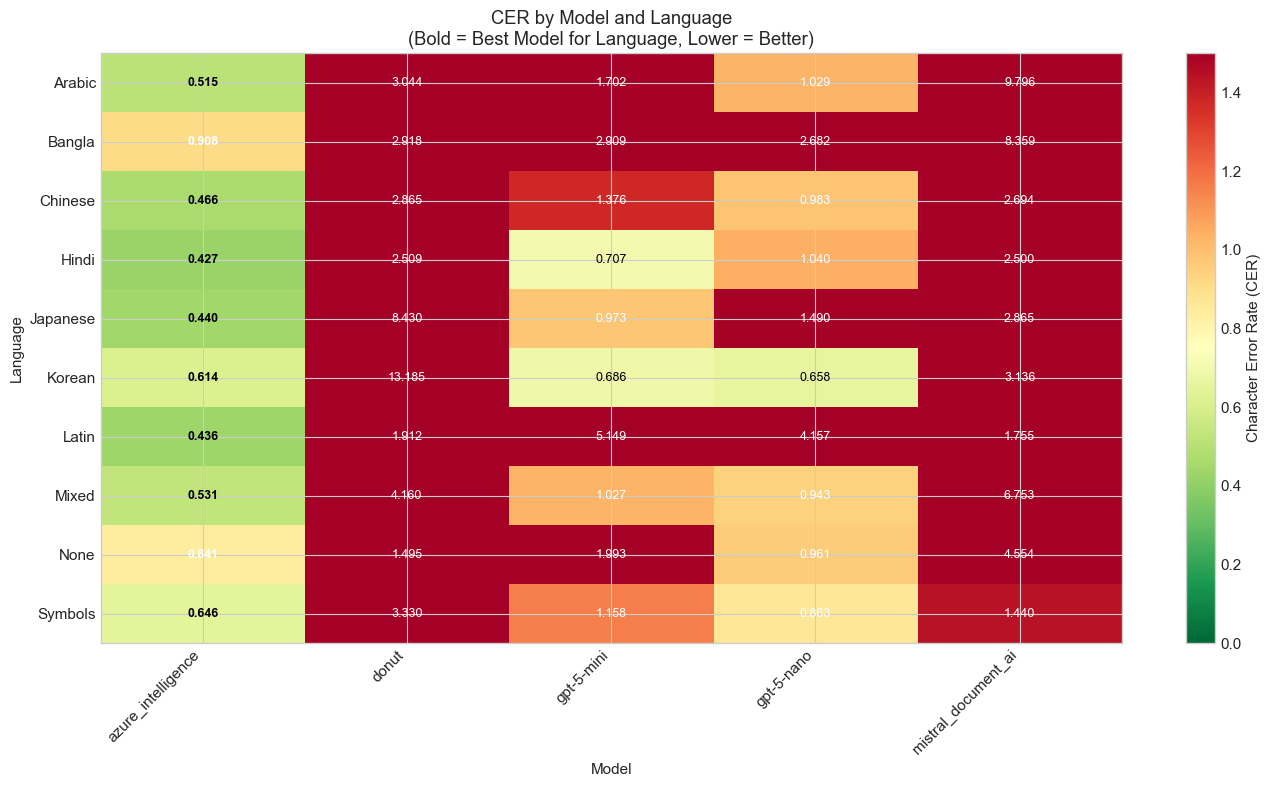

In [38]:
# Create pivot table for heatmap
pivot_cer = lang_model_perf.pivot(index='Language', columns='Model', values='CER Mean')

# Reorder languages
lang_order = [l for l in TARGET_LANGUAGES if l in pivot_cer.index]
pivot_ordered = pivot_cer.loc[lang_order]

# Create heatmap
fig, ax = plt.subplots(figsize=(14, 8))
im = ax.imshow(pivot_ordered.values, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=1.5)

# Add colorbar
cbar = plt.colorbar(im, ax=ax, label='Character Error Rate (CER)')

# Set ticks
ax.set_xticks(range(len(pivot_ordered.columns)))
ax.set_xticklabels(pivot_ordered.columns, rotation=45, ha='right')
ax.set_yticks(range(len(pivot_ordered.index)))
ax.set_yticklabels(pivot_ordered.index)

# Add text annotations
for i in range(len(pivot_ordered.index)):
    for j in range(len(pivot_ordered.columns)):
        val = pivot_ordered.iloc[i, j]
        if not pd.isna(val):
            # Check if this is the best model for this language
            is_best = (pivot_ordered.iloc[i, :].min() == val)
            text_color = 'white' if val > 0.75 else 'black'
            weight = 'bold' if is_best else 'normal'
            ax.text(j, i, f'{val:.3f}', ha='center', va='center', 
                    color=text_color, fontweight=weight, fontsize=9)

ax.set_xlabel('Model')
ax.set_ylabel('Language')
ax.set_title('CER by Model and Language\n(Bold = Best Model for Language, Lower = Better)')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'cer_heatmap_by_language.png', dpi=150, bbox_inches='tight')
plt.show()

### 9.3 Bar Charts: CER by Language for Each Model

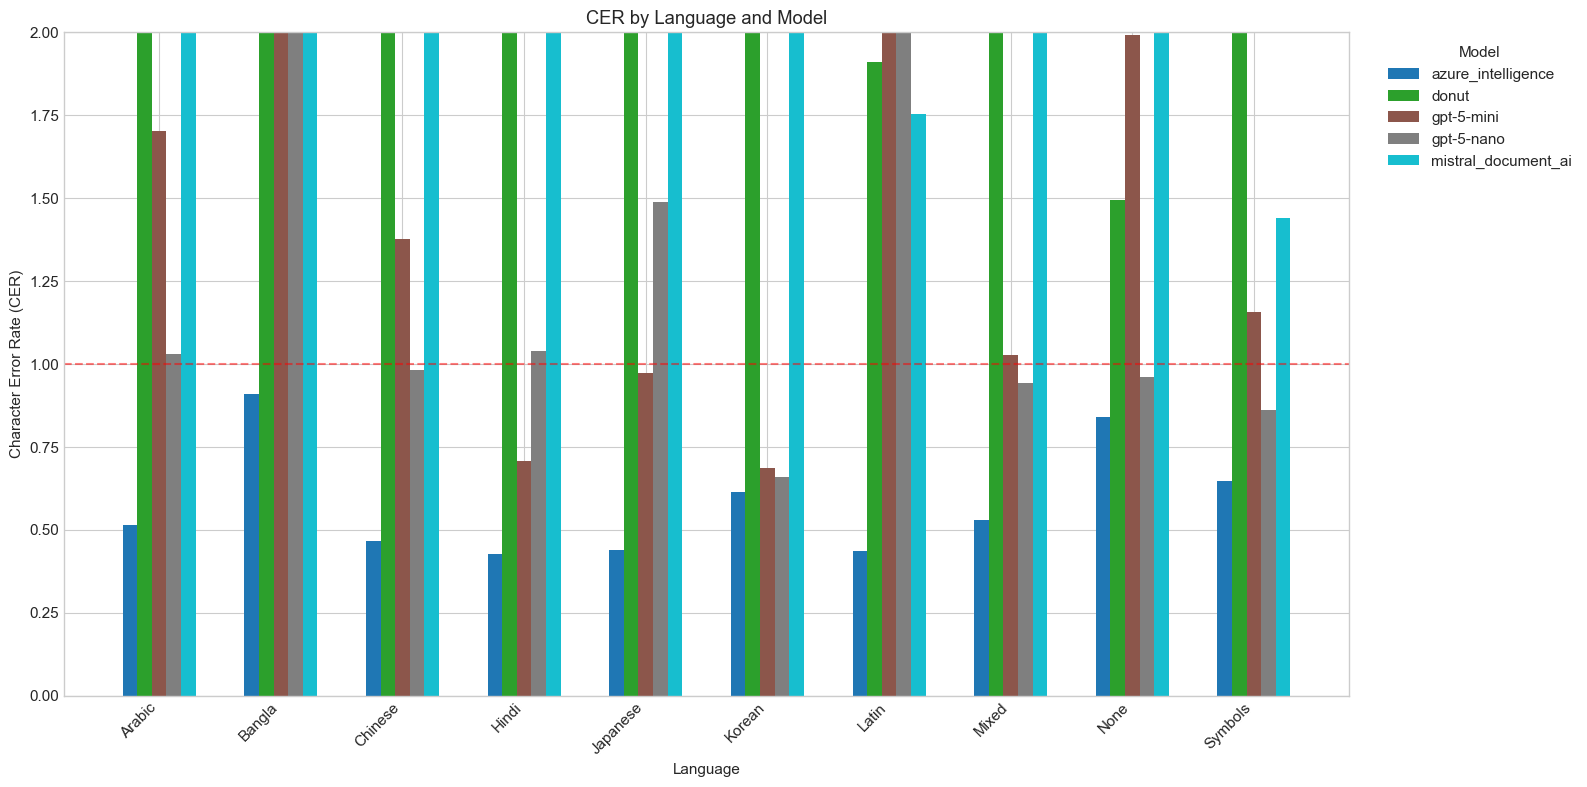

In [45]:
# Grouped bar chart: CER by Language, grouped by Model
models = sorted(metrics_filtered['model'].unique())
languages = [l for l in TARGET_LANGUAGES if l in metrics_filtered['language_simplified'].unique()]

fig, ax = plt.subplots(figsize=(16, 8))

x = np.arange(len(languages))
width = 0.12  # Width of bars
n_models = len(models)

# Color palette for models
model_colors = plt.cm.tab10(np.linspace(0, 1, n_models))

for i, model in enumerate(models):
    model_data = lang_model_perf[lang_model_perf['Model'] == model]
    cer_values = []
    for lang in languages:
        val = model_data[model_data['Language'] == lang]['CER Mean'].values
        cer_values.append(val[0] if len(val) > 0 else 0)
    
    offset = (i - n_models/2 + 0.5) * width
    bars = ax.bar(x + offset, cer_values, width, label=model, color=model_colors[i])

ax.set_xlabel('Language')
ax.set_ylabel('Character Error Rate (CER)')
ax.set_title('CER by Language and Model')
ax.set_xticks(x)
ax.set_xticklabels(languages, rotation=45, ha='right')
ax.legend(title='Model', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_ylim(0, min(2.0, lang_model_perf['CER Mean'].max() * 1.1))
ax.axhline(y=1.0, color='red', linestyle='--', alpha=0.5, label='CER=1.0')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'cer_grouped_by_language.png', dpi=150, bbox_inches='tight')
plt.show()

### 9.4 Per-Language Performance Breakdown

Individual bar charts showing model performance for each language.

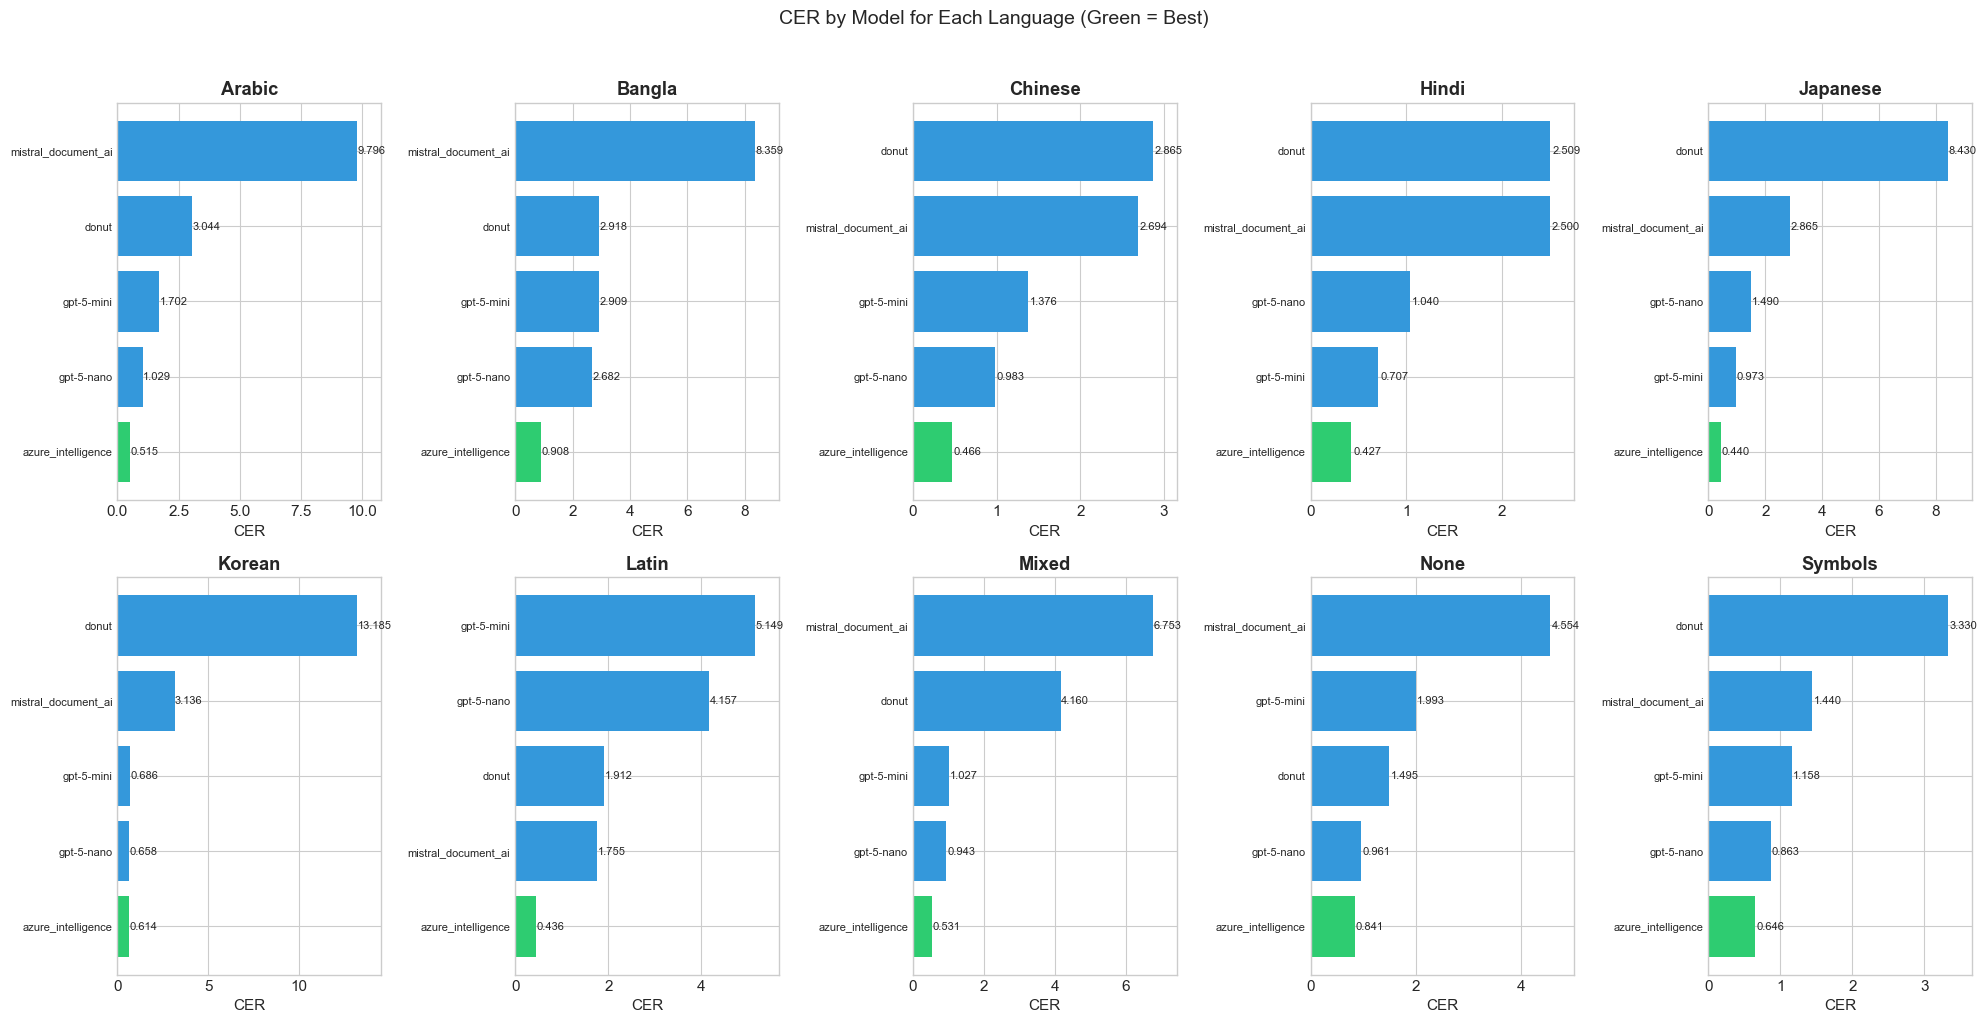

In [40]:
# Create individual bar charts for each language
fig, axes = plt.subplots(2, 5, figsize=(20, 10))
axes = axes.flatten()

for idx, lang in enumerate(languages):
    ax = axes[idx]
    lang_data = lang_model_perf[lang_model_perf['Language'] == lang].sort_values('CER Mean')
    
    colors_list = ['#2ecc71' if v == lang_data['CER Mean'].min() else '#3498db' 
                   for v in lang_data['CER Mean']]
    
    bars = ax.barh(range(len(lang_data)), lang_data['CER Mean'], color=colors_list)
    ax.set_yticks(range(len(lang_data)))
    ax.set_yticklabels(lang_data['Model'], fontsize=8)
    ax.set_xlabel('CER')
    ax.set_title(f'{lang}', fontweight='bold')
    ax.set_xlim(0, max(1.5, lang_data['CER Mean'].max() * 1.1))
    
    # Add value labels
    for i, (bar, val) in enumerate(zip(bars, lang_data['CER Mean'])):
        ax.text(val + 0.02, bar.get_y() + bar.get_height()/2, 
                f'{val:.3f}', va='center', fontsize=8)

# Remove extra subplots if any
for idx in range(len(languages), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('CER by Model for Each Language (Green = Best)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'cer_per_language_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()

### 9.5 Phase Comparison by Language

Compare OCR (Phase 1) vs VLM (Phase 2/3) performance for each language.

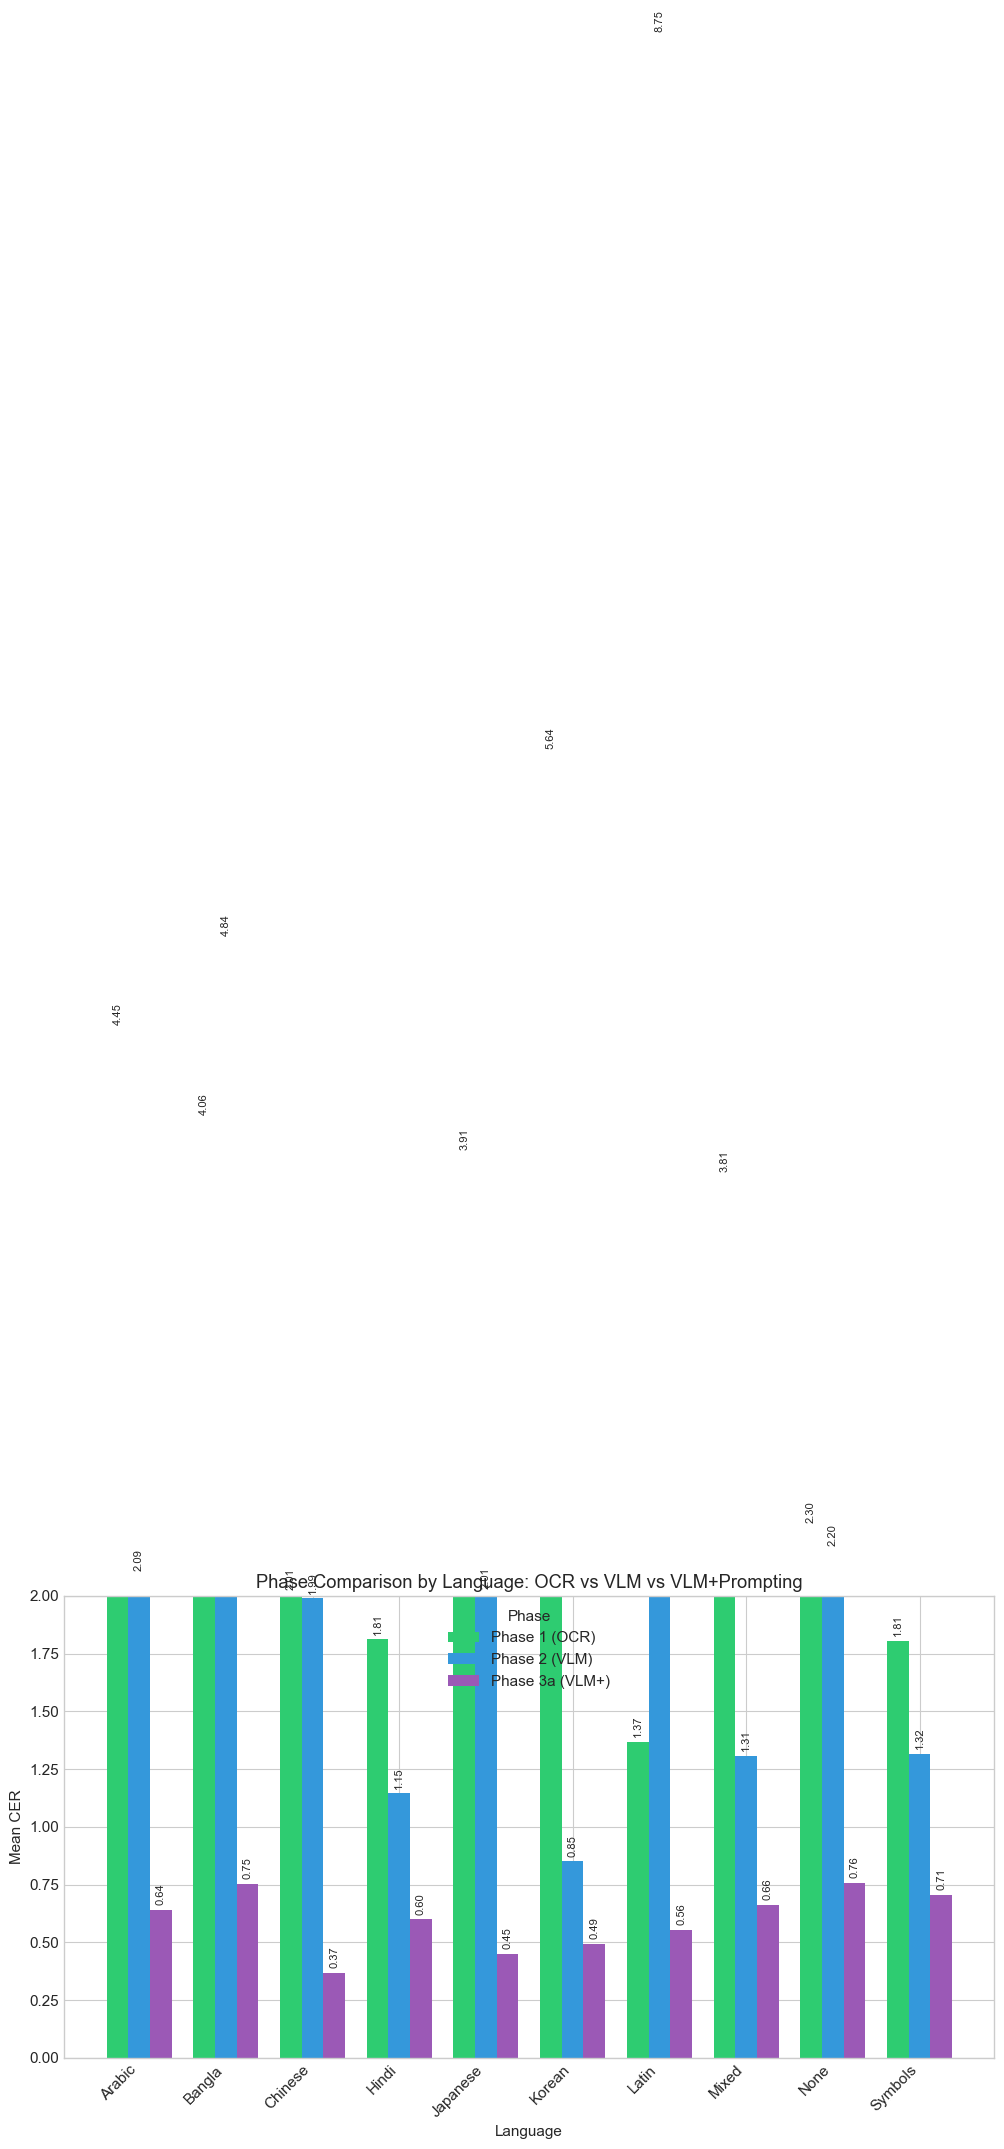

In [41]:
# Compare phases by language
phase_lang_perf = metrics_filtered.groupby(['language_simplified', 'phase']).agg({
    'cer': 'mean',
    'wer': 'mean'
}).round(4).reset_index()

# Pivot for phase comparison
phase_pivot = phase_lang_perf.pivot(index='language_simplified', columns='phase', values='cer')
phase_pivot = phase_pivot.loc[[l for l in TARGET_LANGUAGES if l in phase_pivot.index]]

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(phase_pivot.index))
width = 0.25
phase_colors = {'Phase 1 (OCR)': '#2ecc71', 'Phase 2 (VLM)': '#3498db', 'Phase 3a (VLM+)': '#9b59b6'}

for i, (phase, color) in enumerate(phase_colors.items()):
    if phase in phase_pivot.columns:
        offset = (i - 1) * width
        bars = ax.bar(x + offset, phase_pivot[phase], width, label=phase, color=color)
        # Add value labels
        for bar, val in zip(bars, phase_pivot[phase]):
            if not pd.isna(val):
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                        f'{val:.2f}', ha='center', va='bottom', fontsize=8, rotation=90)

ax.set_xlabel('Language')
ax.set_ylabel('Mean CER')
ax.set_title('Phase Comparison by Language: OCR vs VLM vs VLM+Prompting')
ax.set_xticks(x)
ax.set_xticklabels(phase_pivot.index, rotation=45, ha='right')
ax.legend(title='Phase')
ax.set_ylim(0, min(2.0, phase_pivot.max().max() * 1.3))

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'phase_comparison_by_language.png', dpi=150, bbox_inches='tight')
plt.show()

### 9.6 Summary Table: Best Models by Language

In [42]:
# Create comprehensive summary table
summary_table = []

for lang in languages:
    lang_data = lang_model_perf[lang_model_perf['Language'] == lang].copy()
    
    if len(lang_data) == 0:
        continue
    
    # Best and worst models
    best_row = lang_data.loc[lang_data['CER Mean'].idxmin()]
    worst_row = lang_data.loc[lang_data['CER Mean'].idxmax()]
    
    summary_table.append({
        'Language': lang,
        'Best Model': best_row['Model'],
        'Best CER': best_row['CER Mean'],
        'Best WER': best_row['WER Mean'],
        'Worst Model': worst_row['Model'],
        'Worst CER': worst_row['CER Mean'],
        'CER Range': worst_row['CER Mean'] - best_row['CER Mean'],
        'Samples': int(lang_data['Sample Count'].sum() / len(lang_data))  # Samples per model
    })

summary_table_df = pd.DataFrame(summary_table)
summary_table_df = summary_table_df.round(4)

print("Summary: Best and Worst Models by Language")
print("=" * 100)
summary_table_df

Summary: Best and Worst Models by Language


,Language,Best Model,Best CER,Best WER,Worst Model,Worst CER,CER Range,Samples
0,Arabic,azure_intelligence,0.5149,0.6695,mistral_document_ai,9.7957,9.2808,63
1,Bangla,azure_intelligence,0.9084,1.0514,mistral_document_ai,8.3589,7.4505,81
2,Chinese,azure_intelligence,0.4657,0.7410,donut,2.8645,2.3988,67
3,Hindi,azure_intelligence,0.4269,0.6128,donut,2.5091,2.0822,68
4,Japanese,azure_intelligence,0.4402,0.7824,donut,8.4299,7.9897,60
5,Korean,azure_intelligence,0.6137,0.9960,donut,13.1846,12.5709,51
6,Latin,azure_intelligence,0.4365,0.7166,gpt-5-mini,5.1493,4.7128,23
7,Mixed,azure_intelligence,0.5312,0.8135,mistral_document_ai,6.7534,6.2222,71
8,None,azure_intelligence,0.8408,1.2819,mistral_document_ai,4.5539,3.7131,95
9,Symbols,azure_intelligence,0.6461,0.8390,donut,3.3304,2.6843,117


In [43]:
# Save language analysis results
lang_model_perf.to_csv(RESULTS_DIR / 'language_model_performance.csv', index=False)
print(f"Saved language-model performance to: {RESULTS_DIR / 'language_model_performance.csv'}")

summary_table_df.to_csv(RESULTS_DIR / 'best_model_by_language.csv', index=False)
print(f"Saved best model by language to: {RESULTS_DIR / 'best_model_by_language.csv'}")

# Full pivot table
pivot_cer.to_csv(RESULTS_DIR / 'cer_pivot_language_model.csv')
print(f"Saved CER pivot table to: {RESULTS_DIR / 'cer_pivot_language_model.csv'}")

Saved language-model performance to: ../results_postprocessing/ICDAR_mini/language_model_performance.csv
Saved best model by language to: ../results_postprocessing/ICDAR_mini/best_model_by_language.csv
Saved CER pivot table to: ../results_postprocessing/ICDAR_mini/cer_pivot_language_model.csv


## 10. Export Results

Save the analysis results for further use.

In [44]:
# Save detailed metrics
all_metrics.to_csv(RESULTS_DIR / 'detailed_metrics.csv', index=False)
print(f"Saved detailed metrics to: {RESULTS_DIR / 'detailed_metrics.csv'}")

# Save summary comparison
comparison_df.to_csv(RESULTS_DIR / 'model_comparison.csv', index=False)
print(f"Saved model comparison to: {RESULTS_DIR / 'model_comparison.csv'}")

# Save sample-level pivot
sample_pivot.to_csv(RESULTS_DIR / 'sample_level_cer.csv', index=False)
print(f"Saved sample-level CER to: {RESULTS_DIR / 'sample_level_cer.csv'}")

print("\nAll exports complete!")

Saved detailed metrics to: ../results_postprocessing/ICDAR_mini/detailed_metrics.csv
Saved model comparison to: ../results_postprocessing/ICDAR_mini/model_comparison.csv
Saved sample-level CER to: ../results_postprocessing/ICDAR_mini/sample_level_cer.csv

All exports complete!


## Summary & Conclusions

### Key Findings:

1. **OCR vs VLM Performance**: Compare the CER/WER metrics between Phase 1 (OCR) and Phase 2/3 (VLM) models.

2. **Impact of Prompting**: Compare Phase 2 (generic prompts) vs Phase 3a (task-aware prompts) to determine if prompting improves VLM performance.

3. **Best Performing Models**: Identify which models achieve the lowest error rates.

4. **Language-Specific Performance**: Understand how models perform across different scripts (Latin, Arabic, etc.)

### Next Steps:
- Run additional VLM models to expand comparison
- Test different prompting strategies
- Analyze failure cases in detail